In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brendan45774/test-file")

print("Path to dataset files:", path)


100%|██████████| 11.2k/11.2k [00:00<00:00, 12.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brendan45774/test-file/versions/6


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


загрузка данных

In [ ]:
data = pd.read_csv(path + '/tested.csv')
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
data.index

RangeIndex(start=0, stop=418, step=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


descriptive statictics

In [ ]:
data['Survived'].value_counts()

,count
Survived,
0,266
1,152


In [ ]:
data['Survived'].value_counts()[0]

266

In [ ]:
data.Survived.value_counts()

,count
Survived,
0,266
1,152


тут должно быть одно слово, без пробелов


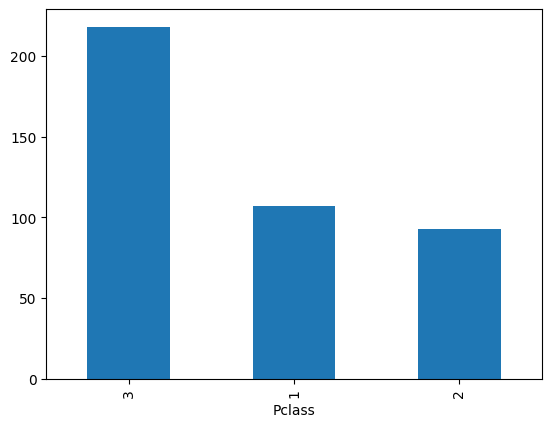

In [ ]:
data['Pclass'].value_counts().plot(kind="bar")

plt.show()

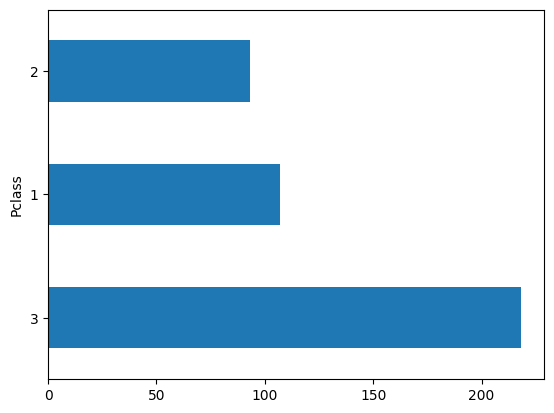

In [ ]:
data['Pclass'].value_counts().plot(kind="barh")

plt.show()

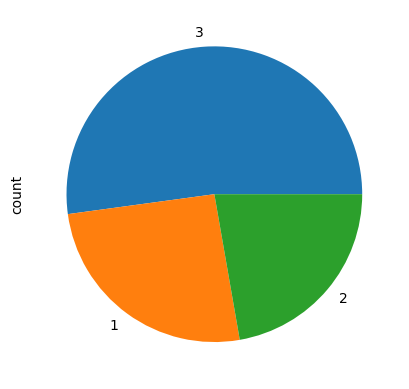

In [ ]:
data['Pclass'].value_counts().plot(kind="pie")

plt.show()

In [ ]:
data['Age'].value_counts()

,count
Age,
21.0,17
24.0,17
22.0,16
30.0,15
18.0,13
...,...
76.0,1
28.5,1
22.5,1


In [ ]:
data['Age'].describe()

,Age
count,332.000000
mean,30.272590
std,14.181209
min,0.170000
25%,21.000000
50%,27.000000
75%,39.000000
max,76.000000


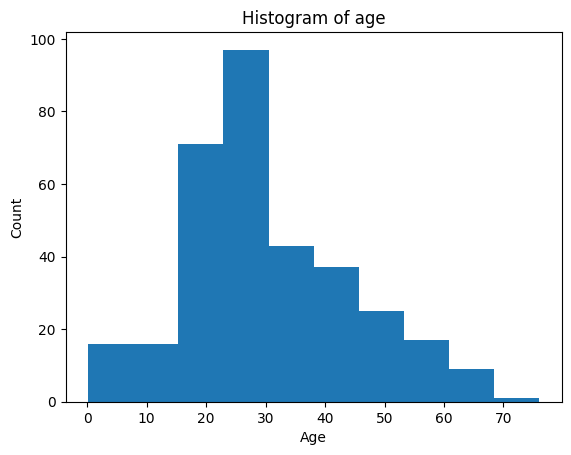

In [ ]:
plt.hist(data['Age'])
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Histogram of age")

plt.show()

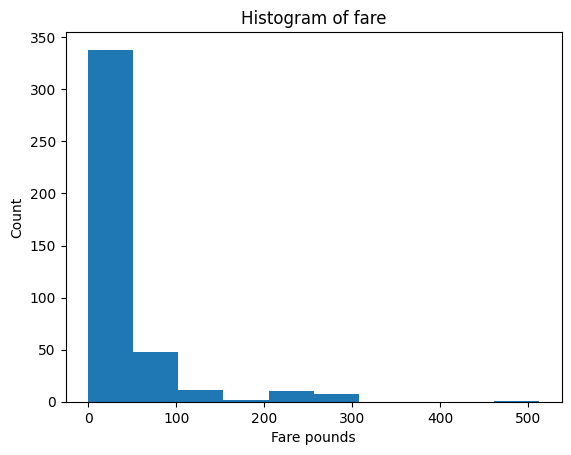

In [ ]:
plt.hist(data['Fare'])
plt.xlabel("Fare pounds")
plt.ylabel("Count")
plt.title("Histogram of fare")

plt.show()

In [ ]:
data["Fare"].describe()

,Fare
count,417.000000
mean,35.627188
std,55.907576
min,0.000000
25%,7.895800
50%,14.454200
75%,31.500000
max,512.329200


## agregeating grouping pivoting

In [ ]:
data.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.467290
2,0.322581
3,0.330275


In [ ]:
data.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,1.0
male,0.0


In [ ]:
data[data["Sex"]=="female"]["Survived"].value_counts()

,count
Survived,
1,152


In [ ]:
data[data["Sex"]=="male"]["Survived"].value_counts()

,count
Survived,
0,266


In [ ]:
data.pivot_table(index='Embarked', columns='Pclass', values='Survived', aggfunc='mean')

Pclass,1,2,3
Embarked,,,
C,0.50,0.363636,0.228571
Q,1.00,0.000000,0.560976
S,0.42,0.333333,0.288732


In [ ]:
data.pivot_table(index='Pclass', columns='Sex', values='PassengerId', aggfunc="count")

Sex,female,male
Pclass,,
1,50,57
2,30,63
3,72,146


<Axes: xlabel='Pclass', ylabel='count'>

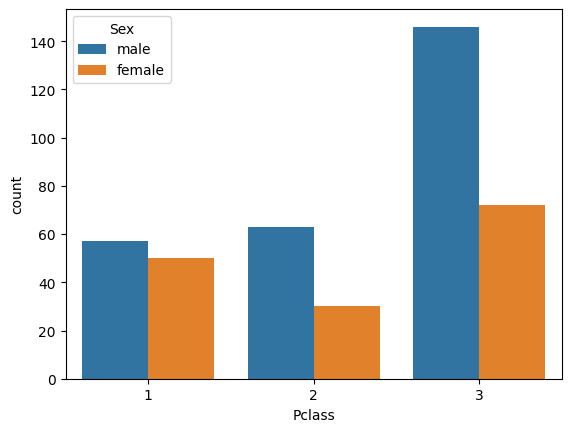

In [ ]:
import seaborn as sns
sns.countplot(data=data,x="Pclass",hue="Sex")

In [ ]:
data.groupby("Survived")["Age"].agg(['min','max', 'mean','median'])

,min,max,mean,median
Survived,,,,
0,0.33,67.0,30.272732,27.0
1,0.17,76.0,30.272362,27.0
